# Exercise 5

### Computer Vision, Fall 2026

#### Name: <font color='blue'>*Sepeteus Rosenlöf*</font>
---
**Instructions:**

- Return the answer in PDF and Jupyter Notebook formats.

- Return latest on<font color='red'> Wednesday 07.10.2026 at 16.00</font> via Moodle.


Disclosure, I used Gemini's guided learning to do these.

## Ex 5.1. Stereo rectification (3p)
In computer vision, stereo cameras are used to recover depth information, in a process called stereo reconstruction. An important step of this process is **stereo rectification**, which aligns two images to the same plane. During the lecture you have learned a procedure for **stereo rectification** given calibrated cameras. In this exercise you will perform **stereo rectification** for uncalibrated cameras, using OpenCV method `stereoRectifyUncalibrated()` [OpenCV documentation link](https://docs.opencv.org/3.4/d9/d0c/group__calib3d.html#gaadc5b14471ddc004939471339294f052:~:text=%E2%97%86-,stereoRectifyUncalibrated,-()).

Tasks:

- a) Write stereo rectification code using the provided helper methods and OpenCV. Your code should plot the rectified images, epipolar lines on non-rectified images and epipolar lines on rectified images.
- b) Answer the questions: what happens to epipolar lines after stereo rectification? Why is that useful for stereo reconstruction?

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Helper methods, do not modify
def plot_imgs(img1, img2):
    """Plot two images side by side.
    Args:
        img1 - first image to plot
        img2 - second image to plot
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Display the first image
    axes[0].imshow(img1)
    axes[0].axis('off')  # Turn off axis for better visualization
    axes[0].set_title('Image 1')

    # Display the second image
    axes[1].imshow(img2)
    axes[1].axis('off')  # Turn off axis for better visualization
    axes[1].set_title('Image 2')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

def get_keypoints(gray1, gray2):
    """Detect and match keypoints in two grayscale images.
    Args:
        gray1 - first grayscale image
        gray2 - second grayscale image
    """
    # Detect and compute features (ORB for simplicity)
    orb = cv2.ORB_create(5000)
    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    # Match features
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Extract matched keypoints
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

    return pts1, pts2

def visualize_epipolar_lines(img1, img2, pts1, pts2, fundamental_matrix):
    """Find and draw epipolar lines on the images.
    Args:
        img1 - left image from the stereo pair
        img2 - right image from the stereo pair
        pts1 - keypoints in the left image
        pts2 - keypoints in the right image
        fundamental_matrix - computed fundamental matrix
    """
    
    def drawlines(img1, img2, lines, pts1, pts2):
        r, c, _ = img1.shape       
        # Use the same random seed so that two images are comparable!
        np.random.seed(0)
        for r, pt1, pt2 in zip(lines, np.int32(pts1), np.int32(pts2)):
            color = tuple(np.random.randint(0, 255, 3).tolist())
            x0, y0 = map(int, [0, -r[2]/r[1]])
            x1, y1 = map(int, [c, -(r[2]+r[0]*c)/r[1]])
            img1 = cv2.line(img1, (x0, y0), (x1, y1), color, 1)
            img1 = cv2.circle(img1, tuple(pt1), 5, color, -1)
            img2 = cv2.circle(img2, tuple(pt2), 5, color, -1)
        return img1, img2

    lines1 = cv2.computeCorrespondEpilines(
        pts2.reshape(-1, 1, 2), 2, fundamental_matrix)
    lines1 = lines1.reshape(-1, 3)
    img1_with_epi, _ = drawlines(img1, img2, lines1, pts1, pts2)

    # Find epilines corresponding to points in left image (first image) and
    # drawing its lines on right image
    lines2 = cv2.computeCorrespondEpilines(
        pts1.reshape(-1, 1, 2), 1, fundamental_matrix)
    lines2 = lines2.reshape(-1, 3)
    img2_with_epi, _ = drawlines(img2, img1, lines2, pts2, pts1)

    return img1_with_epi, img2_with_epi

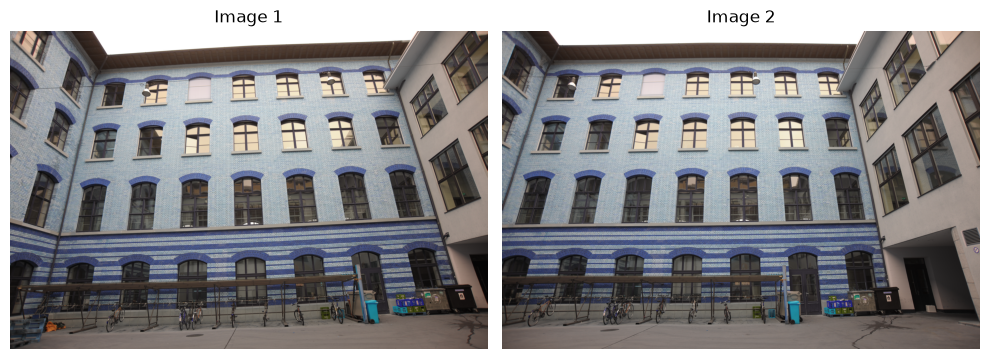

In [12]:
# Initialization code, do not modify
# 1. Load stereo images
img1 = cv2.imread('images-ex5/courtyard_left.JPG')
img2 = cv2.imread('images-ex5/courtyard_right.JPG')
plot_imgs(img1, img2)

# 2. Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

### a)

Write your code in cells below

In [48]:
# Perform stereo rectification and plot the rectified images

kp1,kp2 = get_keypoints(gray1, gray2)
fund_mtx, mask = cv2.findFundamentalMat(kp1, kp2, cv2.FM_RANSAC)
img_dims = (gray1.shape[1], gray1.shape[0])
filtered_kp1 = kp1[mask.ravel() == 1]
filtered_kp2 = kp2[mask.ravel() == 1]
_, H1, H2 = cv2.stereoRectifyUncalibrated(filtered_kp1, filtered_kp2, fund_mtx, img_dims)

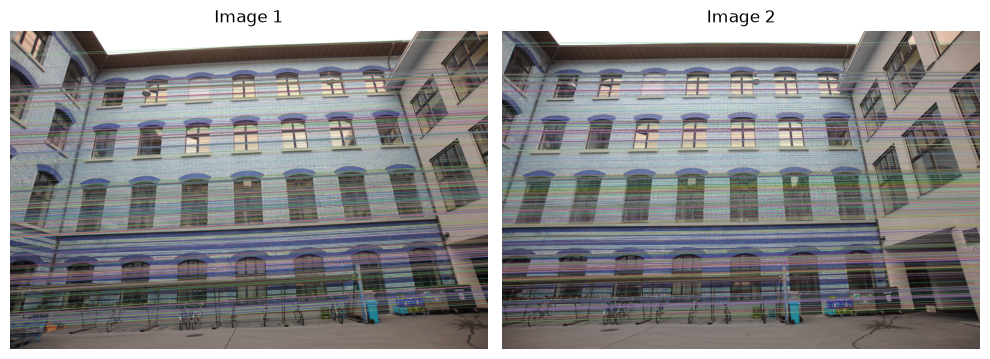

In [49]:
# Plot epipolar lines on original images
img1_epi, img2_epi = visualize_epipolar_lines(img1, img2, filtered_kp1, filtered_kp2, fund_mtx)

plot_imgs(img1_epi, img2_epi)

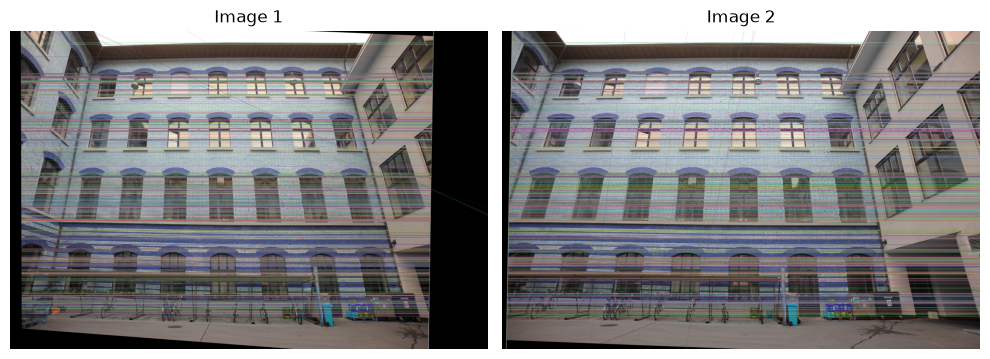

In [56]:
# Visualize epipolar lines on rectified images
# Hint: Think carefully about the order of the operations performed, so that the epipolar lines are drawn correctly.
img1_rect = cv2.warpPerspective(img1, H1, img_dims)
img2_rect = cv2.warpPerspective(img2, H2, img_dims)
kp1_rect,kp2_rect = get_keypoints(img1_rect, img2_rect)

fund_mtx_rect, rect_mask= cv2.findFundamentalMat(kp1_rect, kp2_rect, cv2.FM_RANSAC)
filtered_kp1_rect = kp1_rect[rect_mask.ravel() == 1]
filtered_kp2_rect = kp2_rect[rect_mask.ravel() == 1]

# Fundamental matrix for rectified images becomes a simple cross-product matrix (or compute from transformed points)
img1_rect_epi, img2_rect_epi = visualize_epipolar_lines(img1_rect, img2_rect, filtered_kp1_rect, filtered_kp2_rect, fund_mtx_rect)

plot_imgs(img1_rect_epi, img2_rect_epi)

### b)

- The epipolar lines align horizontally and vertically after rectification. You could now draw a straight line horizontally from one image to another.
- Now every point will sit on the same horizontal line between both images making mapping easier. We no longer need to worry about handling the y-axis and angles.
 


## Ex 5.2 Stereo disparity from rectified images (2p)
In this exercise you will use the rectified images from the previous exercise to estimate stereo disparity. Stereo disparity is the difference in pixels between object locations in the images. It can be used to calculate depth.

a) Write code that calculates the stereo disparity between the images you rectified in previous exercise. Use the OpenCV class **StereoSGBM**. Tweak the parameters of the function to get a sensible result. Plot the disparity.

b) Use the disparity to provide a (pseudo) depth estimate. Assume values of focal length **f** and baseline **B** that lead to sensible depth values. Plot your depth estimate.

### Answers:

### a)

In [57]:
# Perform stereo disparity calculation
block_size = 3
num_channels = 3  # Assuming an RGB or BGR image pipeline

stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=64,  # Must be divisible by 16
    blockSize=block_size,
    P1=8 * num_channels * block_size ** 2,
    P2=32 * num_channels * block_size ** 2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32,
    mode=cv2.StereoSGBM_MODE_SGBM_3WAY
)

disparity = stereo.compute(img1_rect_epi, img2_rect_epi)

# Convert to CV_8U for normalization and visualization
disparity_visual = cv2.normalize(disparity, None, alpha=0, beta=255, 
                                 norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)



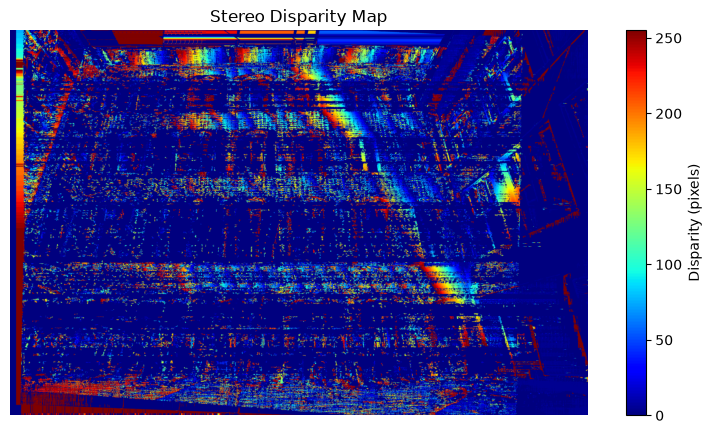

In [61]:
# Plot the disparity
plt.figure(figsize=(10, 5))
plt.imshow(disparity_visual, cmap='jet')
plt.colorbar(label='Disparity (pixels)')
plt.title('Stereo Disparity Map')
plt.axis('off')
plt.show()

### b) 

In [67]:
# Set values of parameters
f = 800
B = 0.1

# Estimate depth
valid_disparity = np.where(disparity > 0, disparity, np.nan)
depth_map = f*B/valid_disparity

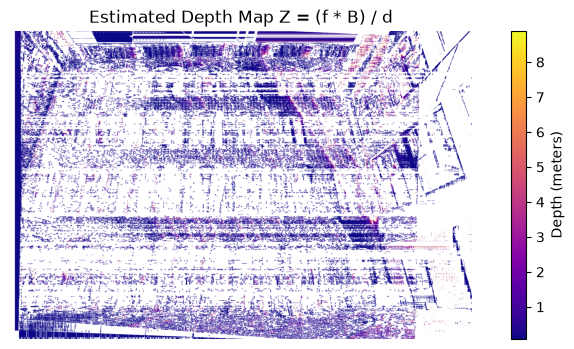

In [68]:
# Plot the depth estimate
plt.figure(figsize=(10, 4))
plt.imshow(depth, cmap='plasma')
plt.colorbar(label='Depth (meters)')
plt.title('Estimated Depth Map Z = (f * B) / d')
plt.axis('off')
plt.show()

## Ex 5.3 Optical flow Lucas-Kanade method (3p)
In this exercise your task is to implement **Lucas-Kanade method** for optical flow estimation and apply it to one provided video and one your own video.

a) Implement the **Lucas-Kanade method**. Put your code inside the function provided below. The function should save video with visualized flow and return last frame of the video. Feel free to use code from OpenCV [tutorial on optical flow](https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html).

b) Apply your implemented function to provided video **Swan.mp4**. Save the resulting video. Plot the last frame. 

c) Record a short video (<5sec) in which **Lucas-Kanade method** fails (*Hint: Think about the assumptions of the method and try to break them*). Apply your implemented function to the video. Save the resulting video. Plot the last frame. Write why the method fails on your video?

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

### a)

In [134]:
def LK_optical_flow(video_path, output_path='output.avi'):
    """Lucas-Kanade optical flow implementation.
    Code based on: https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html
    Args:
        video_path - path to the video file
        output_path - path to save the output video with optical flow visualization
    Returns:
        last_frame - the last frame of the video with optical flow visualization
    """
    


    
    vid = cv2.VideoCapture(video_path)
    color = np.random.randint(0, 255, (100, 3))
    frames = []
    # params for ShiTomasi corner detection
    feature_params = dict( maxCorners = 100,
                           qualityLevel = 0.3,
                           minDistance = 7,
                           blockSize = 7 )
    # Parameters for lucas kanade optical flow
    lk_params = dict( winSize  = (15, 15),
                      maxLevel = 2,
                      criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
    ret, prev_frame = vid.read()
    mask = np.zeros_like(prev_frame)
    prev_frame = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    prev_pts = cv2.goodFeaturesToTrack(prev_frame, mask= None, **feature_params)
    
    #params for video saving
    fps = int(vid.get(cv2.CAP_PROP_FPS))
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    frame_width = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))
    vid_writer = cv2.VideoWriter(output_path, fourcc=fourcc, fps=fps, frameSize=(frame_width, frame_height))
    
    while True:
        ret, frame = vid.read()
        if not ret:
            break
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        if prev_pts is None or len(prev_pts) == 0:
            prev_pts = cv2.goodFeaturesToTrack(prev_frame, mask=None, **feature_params)
            
        nxt_pts, status, _ = cv2.calcOpticalFlowPyrLK(prev_frame, frame_gray, prev_pts, None, **lk_params)
        if nxt_pts is not None and status is not None:
            good_pts_prev = prev_pts[status == 1]
            good_pts_nxt = nxt_pts[status == 1]

        # draw the tracks
        for i, (new, old) in enumerate(zip(good_pts_nxt, good_pts_prev)):
            a, b = new.ravel()
            c, d = old.ravel()
            mask = cv2.line(mask, (int(a), int(b)), (int(c), int(d)), color[i].tolist(), 2)
            frame = cv2.circle(frame, (int(a), int(b)), 5, color[i].tolist(), -1)
        img_frame = cv2.add(frame, mask)
        frames.append(img_frame)
        prev_pts = good_pts_nxt.reshape(-1, 1, 2)
        prev_frame = frame_gray
        vid_writer.write(img_frame)

    vid_writer.release()
    vid.release()
    return img_frame

### b)

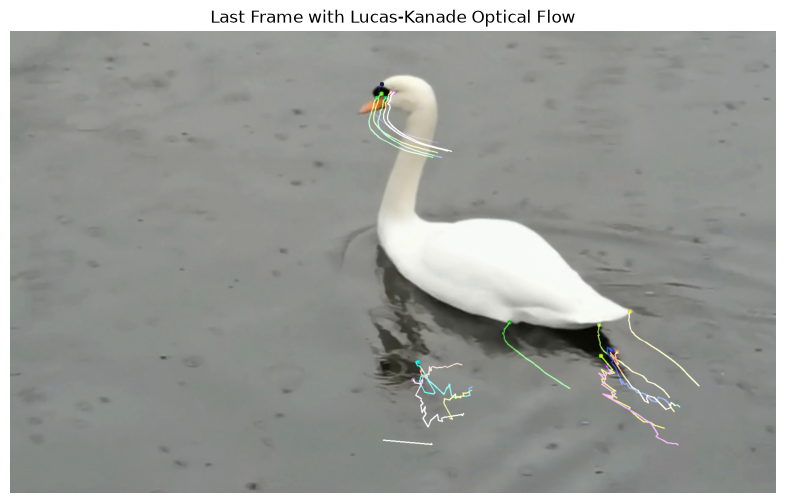

In [135]:
# Apply your implemented function to Swan.mp4
vid_swan = "./images-ex5/Swan.mp4"
last_frame = LK_optical_flow(vid_swan, "./images-ex5/swan_lk.avi")
# Plot the last frame using Matplotlib
plt.figure(figsize=(10, 6))
# Convert BGR (OpenCV format) to RGB (Matplotlib format)
plt.imshow(cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB))
plt.title("Last Frame with Lucas-Kanade Optical Flow")
plt.axis("off")
plt.show()

### c)

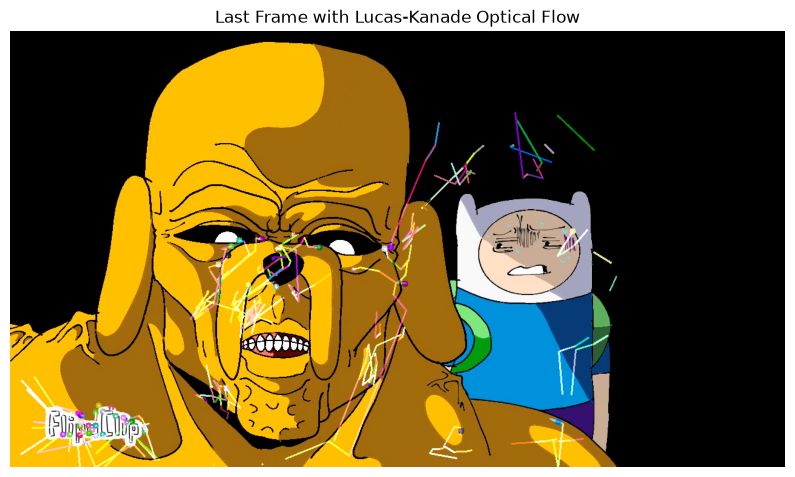

In [136]:
# Apply your implemented function to your own video
vid_test = "./images-ex5/test.mp4"
last_frame = LK_optical_flow(vid_test, "./images-ex5/test_lk.avi")
# Plot the last frame using Matplotlib
plt.figure(figsize=(10, 6))
# Convert BGR (OpenCV format) to RGB (Matplotlib format)
plt.imshow(cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB))
plt.title("Last Frame with Lucas-Kanade Optical Flow")
plt.axis("off")
plt.show()

### Answers

c) Lucas-kanade method relies on continuos smooth movement from frame-to-frame. And little variation on lighting. The fast movements, lighting and other changes throw it off heavily.

# Sources
- Slides for lectures 9 and 10
- Data for stereo rectification: https://www.eth3d.net/datasets, which is available under a license https://creativecommons.org/licenses/by-nc-sa/4.0/
- https://visionbook.mit.edu/multiview.html
- https://www.andreasjakl.com/understand-and-apply-stereo-rectification-for-depth-maps-part-2/


